In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

CSV_PATH   = "pexels_dataset/metadata.csv"
IMG_ROOT   = "pexels_dataset"
SEED       = 42
SAMPLE_N   = 1000
OUTPUT_IMG = "eda_output/"

random.seed(SEED)
df = pd.read_csv(CSV_PATH)
print(f"total data: {len(df)}")
print(df.head())

total data: 49722
                              file                                    title  \
0  cat_animal\cat_animal_00001.jpg                  Close-up of a Tabby Cat   
1  cat_animal\cat_animal_00002.jpg                  Close-up of a Tabby Cat   
2  cat_animal\cat_animal_00003.jpg     Two Cats on a Wall with Feeding Bowl   
3  cat_animal\cat_animal_00004.jpg                          Portrait of Cat   
4  cat_animal\cat_animal_00005.jpg  Close-up of a Resting Cat on Stone Path   

                                             caption     keyword  source  \
0  A close-up of a tabby cat resting on a rock, c...  cat animal  pexels   
1  Portrait of a tabby cat peering over a rock wi...  cat animal  pexels   
2  Two cats perched on a wall, one eating from a ...  cat animal  pexels   
3  Detailed portrait of a tabby cat looking inten...  cat animal  pexels   
4  A serene cat lounging on a stone path, showcas...  cat animal  pexels   

         id                              hash  
0 

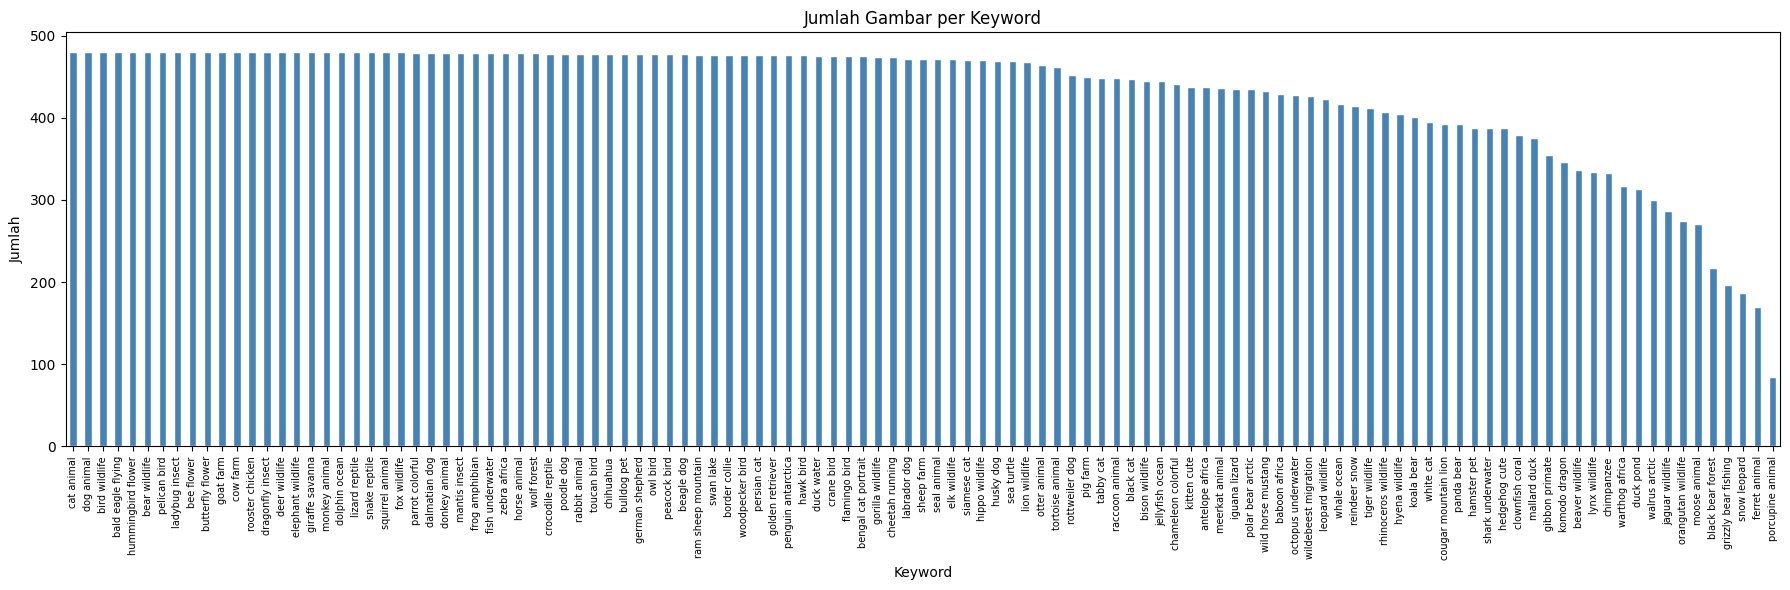

total keyword: 115
min per keyword: 84
max per keyword: 480
rata-rata: 432.4


In [2]:
keyword_counts = df['keyword'].value_counts()

plt.figure(figsize=(18, 6))
keyword_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Jumlah Gambar per Keyword')
plt.xlabel('Keyword')
plt.ylabel('Jumlah')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_keyword_dist.png', dpi=150)
plt.show()

print(f"total keyword: {df['keyword'].nunique()}")
print(f"min per keyword: {keyword_counts.min()}")
print(f"max per keyword: {keyword_counts.max()}")
print(f"rata-rata: {keyword_counts.mean():.1f}")

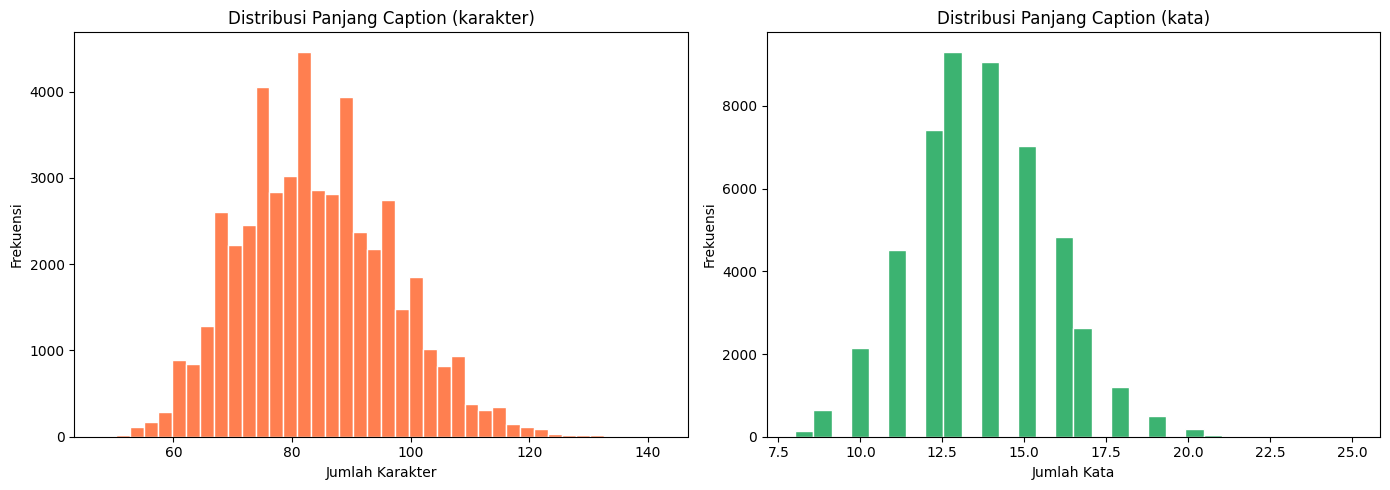

rata-rata karakter : 84.1
rata-rata kata     : 13.7
caption terpendek  : 8 kata
caption terpanjang : 25 kata


In [3]:
df['caption_len']      = df['caption'].apply(lambda x: len(str(x)))
df['caption_wordcount'] = df['caption'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['caption_len'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Distribusi Panjang Caption (karakter)')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['caption_wordcount'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribusi Panjang Caption (kata)')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_caption_dist.png', dpi=150)
plt.show()

print(f"rata-rata karakter : {df['caption_len'].mean():.1f}")
print(f"rata-rata kata     : {df['caption_wordcount'].mean():.1f}")
print(f"caption terpendek  : {df['caption_wordcount'].min()} kata")
print(f"caption terpanjang : {df['caption_wordcount'].max()} kata")

duplikat hash    : 0
duplikat caption : 12
duplikat file    : 0


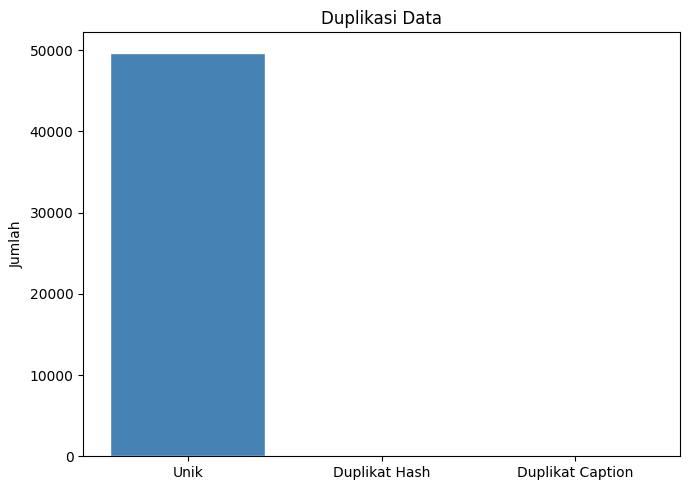

In [4]:
dup_hash    = df['hash'].duplicated().sum()
dup_caption = df['caption'].duplicated().sum()
dup_file    = df['file'].duplicated().sum()

print(f"duplikat hash    : {dup_hash}")
print(f"duplikat caption : {dup_caption}")
print(f"duplikat file    : {dup_file}")

labels = ['Unik', 'Duplikat Hash', 'Duplikat Caption']
values = [len(df) - dup_hash, dup_hash, dup_caption]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=['steelblue', 'tomato', 'orange'], edgecolor='white')
plt.title('Duplikasi Data')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_duplicates.png', dpi=150)
plt.show()

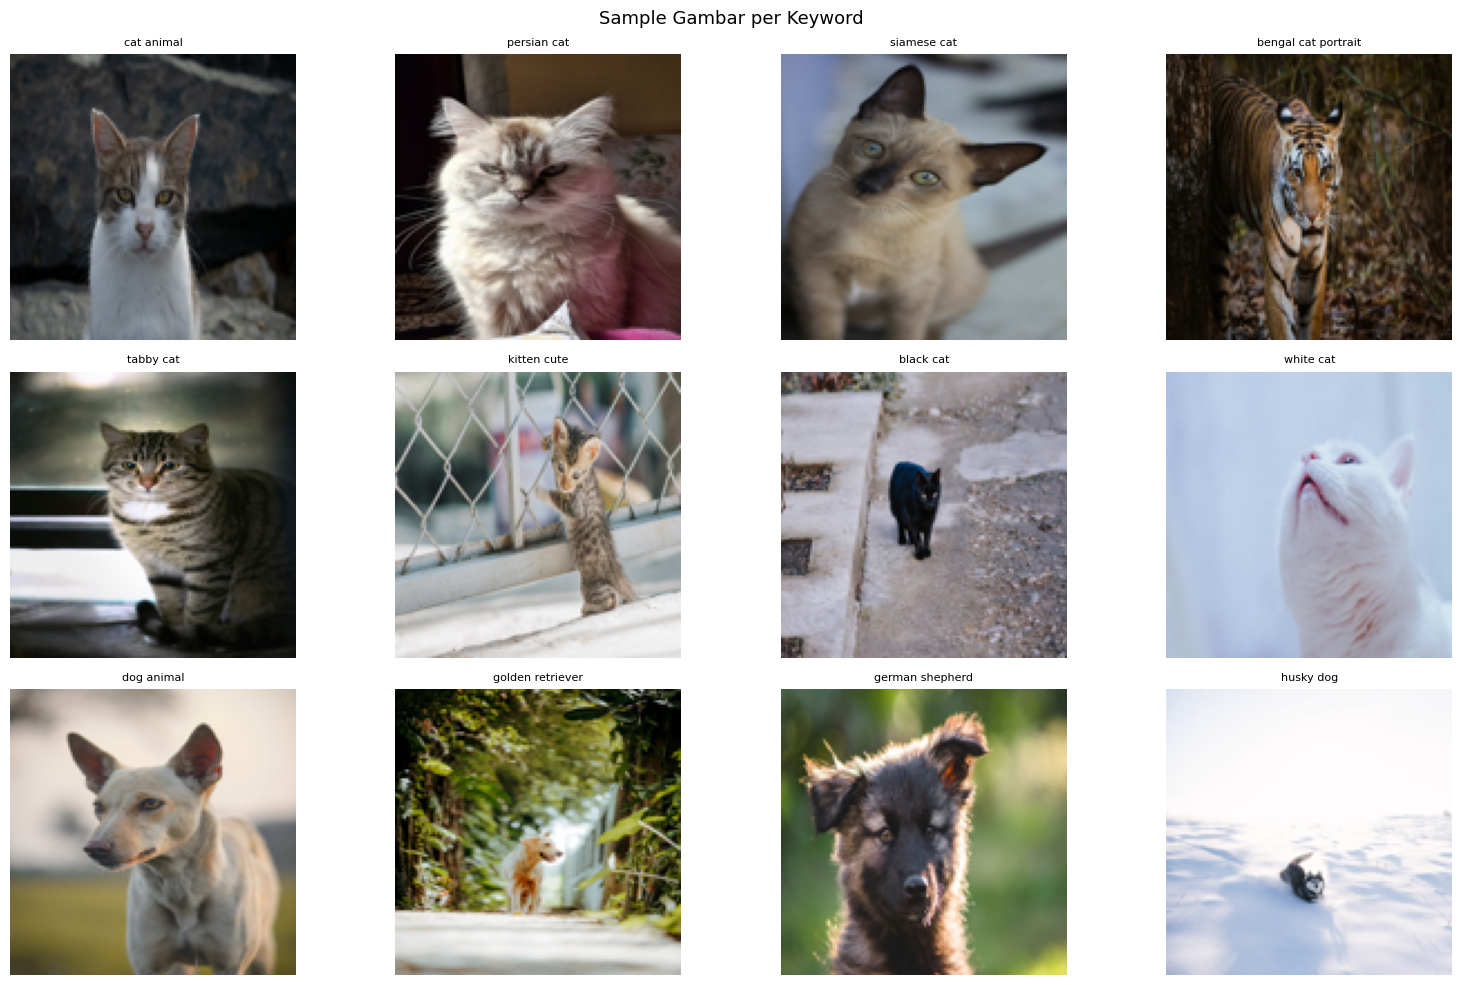

In [5]:
keywords_sample = df['keyword'].unique()[:12]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, kw in enumerate(keywords_sample):
    subset = df[df['keyword'] == kw]
    row    = subset.sample(1, random_state=SEED).iloc[0]
    path   = os.path.join(IMG_ROOT, row['file'].replace('\\', '/'))
    try:
        img = Image.open(path).convert('RGB').resize((128, 128))
        axes[i].imshow(img)
        axes[i].set_title(kw, fontsize=8)
        axes[i].axis('off')
    except:
        axes[i].axis('off')

plt.suptitle('Sample Gambar per Keyword', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_sample_images.png', dpi=150)
plt.show()

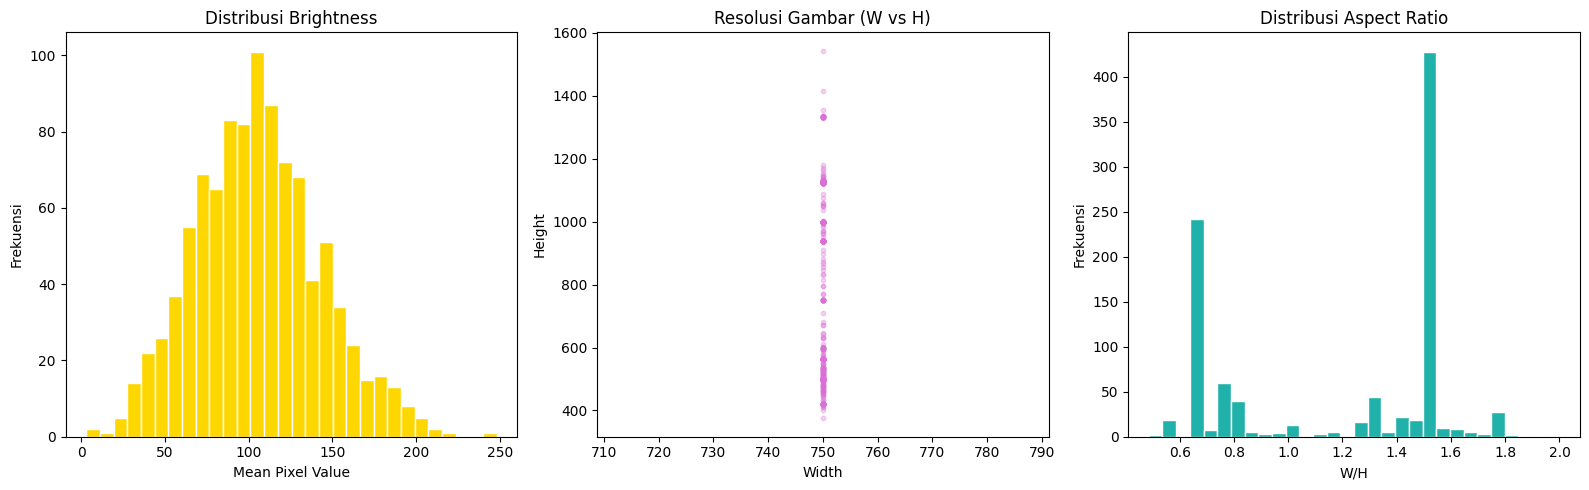

rata-rata brightness : 105.4
rata-rata resolusi   : 750 x 732
rata-rata aspect     : 1.18


In [6]:
sample_df = df.sample(min(SAMPLE_N, len(df)), random_state=SEED).reset_index(drop=True)

brightnesses = []
widths       = []
heights      = []
aspect_ratios = []

for _, row in sample_df.iterrows():
    path = os.path.join(IMG_ROOT, row['file'].replace('\\', '/'))
    try:
        img = Image.open(path).convert('RGB')
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
        arr = np.array(img)
        brightnesses.append(arr.mean())
    except:
        pass

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(brightnesses, bins=30, color='gold', edgecolor='white')
axes[0].set_title('Distribusi Brightness')
axes[0].set_xlabel('Mean Pixel Value')
axes[0].set_ylabel('Frekuensi')

axes[1].scatter(widths, heights, alpha=0.3, s=10, color='orchid')
axes[1].set_title('Resolusi Gambar (W vs H)')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')

axes[2].hist(aspect_ratios, bins=30, color='lightseagreen', edgecolor='white')
axes[2].set_title('Distribusi Aspect Ratio')
axes[2].set_xlabel('W/H')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_pixel_stats.png', dpi=150)
plt.show()

print(f"rata-rata brightness : {np.mean(brightnesses):.1f}")
print(f"rata-rata resolusi   : {np.mean(widths):.0f} x {np.mean(heights):.0f}")
print(f"rata-rata aspect     : {np.mean(aspect_ratios):.2f}")

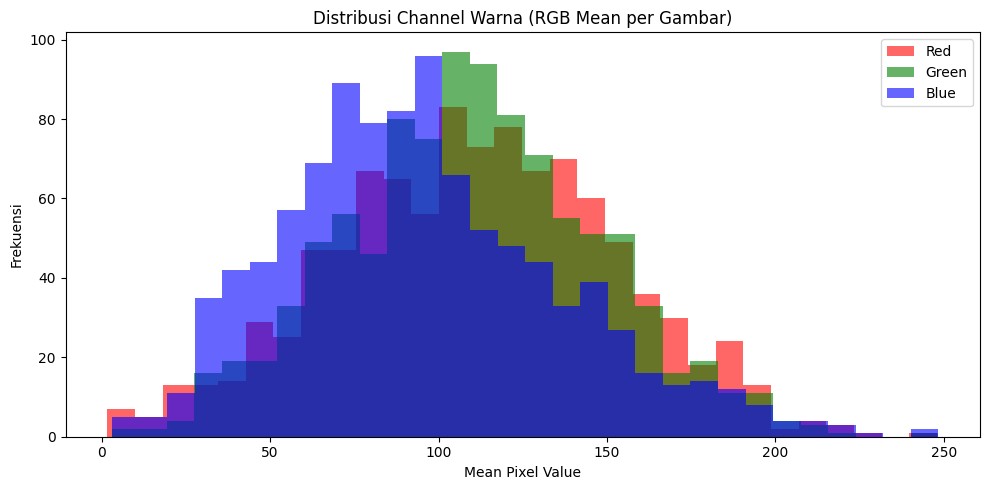

In [7]:
reds, greens, blues = [], [], []

for _, row in sample_df.iterrows():
    path = os.path.join(IMG_ROOT, row['file'].replace('\\', '/'))
    try:
        arr = np.array(Image.open(path).convert('RGB'))
        reds.append(arr[:,:,0].mean())
        greens.append(arr[:,:,1].mean())
        blues.append(arr[:,:,2].mean())
    except:
        pass

plt.figure(figsize=(10, 5))
plt.hist(reds,   bins=30, alpha=0.6, color='red',   label='Red')
plt.hist(greens, bins=30, alpha=0.6, color='green', label='Green')
plt.hist(blues,  bins=30, alpha=0.6, color='blue',  label='Blue')
plt.title('Distribusi Channel Warna (RGB Mean per Gambar)')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_IMG + 'eda_color_dist.png', dpi=150)
plt.show()